In [3]:
import numpy as np
import matplotlib.pyplot as plt

from multiprocessing import Pool
from functools import partial

import OscTools as osc
import OscTools.plot_tools as pt

import OscTools.param_scan as param_scan
from tqdm.notebook import tqdm

import uproot
from scipy.interpolate import RegularGridInterpolator

In [2]:
def load_scan_data(filename):
    data = param_scan.pickle_read(filename)
    
    data_dic = {}
    data_dic['Ue4SQR'] = data[:,2]
    data_dic['Umu4SQR'] = data[:,3]
    s2t = 4*data_dic['Ue4SQR']*data_dic['Umu4SQR']
    data_dic['sin2theta'] = np.round(s2t, decimals=6)
    data_dic['dm4SQR'] = data[:,1]**2
    
    data_dic['MiniApp_chi2'] =  data[:,-3]
    data_dic['MicroApp_chi2'] =  data[:,-2]
    data_dic['MicroApp_Asimov_chi2'] = data[:,-1] 

    data_dic['MiniApp_deltachi2'] = data_dic['MiniApp_chi2'] - np.min(data_dic['MiniApp_chi2'])
    data_dic['MicroApp_deltachi2'] = data_dic['MicroApp_chi2'] - np.min(data_dic['MicroApp_chi2'])
    data_dic['MicroApp_Asimov_deltachi2'] = data_dic['MicroApp_Asimov_chi2'] - np.min(data_dic['MicroApp_Asimov_chi2'])

    return data_dic

def load_scan_data_sbn(filename):
    data = param_scan.pickle_read(filename)
    
    data_dic = {}
    data_dic['Ue4SQR'] = data[:,2]
    data_dic['Umu4SQR'] = data[:,3]
    s2t = 4*data_dic['Ue4SQR']*data_dic['Umu4SQR']
    data_dic['sin2theta'] = np.round(s2t, decimals=6)
    data_dic['dm4SQR'] = data[:,1]**2
    
    data_dic['SBN_chi2'] =  data[:,-1]
    data_dic['SBN_deltachi2'] = data_dic['SBN_chi2'] - np.min(data_dic['SBN_chi2'])

    return data_dic


In [4]:
def add_prospect(original_dic, prospect_file="ProspectTools/PI_DeltaChiSq.root", prospect_tree='DeltaChiSq;1'):
    p0 = uproot.open(prospect_file)
    pros = p0[prospect_tree].to_numpy()
    xPR = pros[1][:-1] + np.diff(pros[1])/2
    yPR = pros[2][:-1] + np.diff(pros[2])/2

    pros_interpolate = RegularGridInterpolator((xPR, yPR), pros[0], bounds_error=False, fill_value=0.0)

    Ue4Sq = original_dic['Ue4SQR']
    DmSq = original_dic['dm4SQR']
    Ue4SqDm4Sq = np.array([Ue4Sq, DmSq]).T
    chi2 = pros_interpolate(Ue4SqDm4Sq)
    original_dic['Prospect_DeltaChi2'] = chi2

    if "MicroApp_chi2" in original_dic.keys():
        original_dic['MicroPros_chi2'] = original_dic['MicroApp_chi2'] + chi2
        original_dic['MicroPros_deltachi2'] = original_dic['MicroPros_chi2'] - np.min(original_dic['MicroPros_chi2'])

    if "MicroApp_Asimov_chi2" in original_dic.keys():
        original_dic['Micro_Asimov_Pros_chi2'] = original_dic['MicroApp_Asimov_chi2'] + chi2
        original_dic['Micro_Asimov_Pros_deltachi2'] = original_dic['Micro_Asimov_Pros_chi2'] - np.min(original_dic['Micro_Asimov_Pros_chi2'])

    if "SBN_chi2" in original_dic.keys():
        original_dic['SBN_Pros_chi2'] = original_dic['SBN_chi2'] + chi2
        original_dic['SBN_Pros_deltachi2'] = original_dic['SBN_Pros_chi2'] - np.min(original_dic['SBN_Pros_chi2'])

    return original_dic

In [5]:
dic_SBN = load_scan_data_sbn('fit_data/SBN_KJK_fullosc_3D_v2.pkl')
dic_SBN = add_prospect(dic_SBN)

dic_SBN_v2 = load_scan_data_sbn('fit_data/SBN_KJK_fullosc_3D_v2.pkl')
dic_SBN_v2 = add_prospect(dic_SBN_v2, prospect_file="/Users/kjkelly/Dropbox/Downloads/P2_HFIR_2Y_Sensitivity_ChiSquare.root", prospect_tree='ChiSquareMap;1')

dic_BooNE = load_scan_data('fit_data/BooNE_KJK_fullosc_3D_v2.pkl')
dic_BooNE = add_prospect(dic_BooNE)

In [6]:
def MutualCompatibility(dicA, dicB, dmsq, chiAkey="MiniApp_deltachi2", chiBkey="MicroApp_deltachi2", same_grid = True, dmsq_tolerance = 0.001, emu_tolerance = 0.0001):
    dmA = dicA['dm4SQR']
    dmB = dicB['dm4SQR']

    if same_grid:
        maskA = dmA == dmsq
        maskB = dmB == dmsq
    else:
        maskA = np.abs(dmA - dmsq) <= dmsq*dmsq_tolerance
        maskB = np.abs(dmB - dmsq) <= dmsq*dmsq_tolerance

    chiA = dicA[chiAkey][maskA]
    chiB = dicB[chiBkey][maskB]

    chiA_max_mask = chiA < 10000
    chiB_max_mask = chiB < 10000

    ch_max = np.min([np.max(chiA[chiA_max_mask]), np.max(chiB[chiB_max_mask])])
    ch_min = np.max([np.min(chiA[chiA_max_mask]), np.min(chiB[chiB_max_mask])])

    chi_sq_threshold_test_vector = np.linspace(ch_min, ch_max, 1000)

    for chi_sq_threshold_test in chi_sq_threshold_test_vector:
        if np.min(chiA) > chi_sq_threshold_test or np.min(chiB) > chi_sq_threshold_test:
            continue
        A_satisfies = np.where(chiA <= chi_sq_threshold_test)
        B_satisfies = np.where(chiB <= chi_sq_threshold_test)

        Ae, Amu = dicA['Ue4SQR'][maskA][A_satisfies], dicA['Umu4SQR'][maskA][A_satisfies]
        Be, Bmu = dicB['Ue4SQR'][maskB][B_satisfies], dicB['Umu4SQR'][maskB][B_satisfies]

        if same_grid:
            nA = len(Ae)
            nB = len(Be)
            #scan over smaller of the two
            if nA <= nB:
                for i in range(nA):
                    if np.any((Ae[i] == Be)*(Amu[i] == Bmu)):
                        return chi_sq_threshold_test
            else:
                for j in range(nB):
                    if np.any((Ae == Be[j])*(Amu == Bmu[j])):
                        return chi_sq_threshold_test
        else:
            #check whether any of the pairs of (Ae, Amu) and (Be, Bmu) are within the tolerance
            #overlap_found = False
            for i in range(len(Ae)):
                for j in range(len(Be)):
                    if np.abs(Ae[i] - Be[j]) < Ae[i]*emu_tolerance and np.abs(Amu[i] - Bmu[j]) < Amu[i]*emu_tolerance:
                        return chi_sq_threshold_test
        #return chi_sq_threshold_test


In [7]:
MutualCompatibility(dic_BooNE, dic_BooNE, np.unique(dic_BooNE['dm4SQR'])[30])

np.float64(9.823211107039278)

In [8]:
MutualCompatibility(dic_BooNE, dic_BooNE, np.unique(dic_BooNE['dm4SQR'])[30], chiBkey="MicroPros_deltachi2")

np.float64(10.724617999573608)

In [9]:
dm_scan = np.unique(dic_BooNE['dm4SQR'])
muC_BooNE = []
for dm in tqdm(dm_scan):
    muC_BooNE.append(MutualCompatibility(dic_BooNE, dic_BooNE, dm))

  0%|          | 0/200 [00:00<?, ?it/s]

In [10]:
dm_scan = np.unique(dic_BooNE['dm4SQR'])
muC_BooNEPROS = []
for dm in tqdm(dm_scan):
    muC_BooNEPROS.append(MutualCompatibility(dic_BooNE, dic_BooNE, dm, chiBkey="MicroPros_deltachi2"))

  0%|          | 0/200 [00:00<?, ?it/s]

In [11]:
muC_BooNE_Asimov = []
for dm in tqdm(dm_scan):
    muC_BooNE_Asimov.append(MutualCompatibility(dic_BooNE, dic_BooNE, dm, chiBkey="MicroApp_Asimov_deltachi2"))

  0%|          | 0/200 [00:00<?, ?it/s]

In [12]:
muC_BooNEPROS_Asimov = []
for dm in tqdm(dm_scan):
    muC_BooNEPROS_Asimov.append(MutualCompatibility(dic_BooNE, dic_BooNE, dm, chiBkey="Micro_Asimov_Pros_deltachi2"))

  0%|          | 0/200 [00:00<?, ?it/s]

In [13]:
muC_SBN = []
for dm in tqdm(dm_scan):
    muC_SBN.append(MutualCompatibility(dic_BooNE, dic_SBN, dm, chiBkey="SBN_deltachi2"))

  0%|          | 0/200 [00:00<?, ?it/s]

In [14]:
muC_SBNPROS_I = []
for dm in tqdm(dm_scan):
    muC_SBNPROS_I.append(MutualCompatibility(dic_BooNE, dic_SBN, dm, chiBkey="SBN_Pros_deltachi2"))

  0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
muC_SBNPROS_II = []
for dm in tqdm(dm_scan):
    muC_SBNPROS_II.append(MutualCompatibility(dic_BooNE, dic_SBN_v2, dm, chiBkey="SBN_Pros_deltachi2"))

  0%|          | 0/200 [00:00<?, ?it/s]

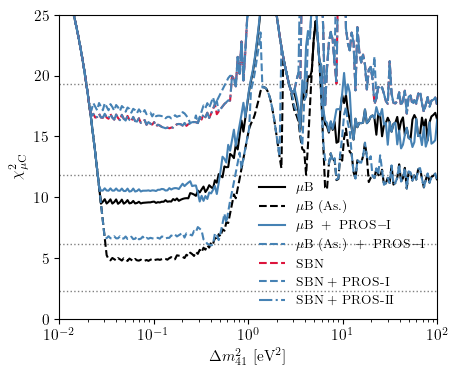

In [16]:
f = [0.14, 0.16, 0.84, 0.76]
fig, ax = pt.std_fig(figsize=(4.5, 4.), ax_form=f)

ax.set_xscale('log')
ax.set_xlabel(r"$\Delta m_{41}^2\ [\mathrm{eV}^2]$", fontproperties=pt.font)
ax.set_ylabel(r"$\chi^2_{\rm \mu C}$", fontproperties=pt.font)

ax.plot(dm_scan, muC_BooNE, color='k', lw=1.5, label=r'$\mathrm{\mu B}$')
ax.plot(dm_scan, muC_BooNE_Asimov, color='k', ls='--', lw=1.5, label=r'$\mathrm{\mu B\ (As.)}$')

ax.plot(dm_scan, muC_BooNEPROS, color='steelblue', lw=1.5, label=r'$\mathrm{\mu B\ +\ PROS{-}I}$')
ax.plot(dm_scan, muC_BooNEPROS_Asimov, color='steelblue', ls='--', lw=1.5, label=r'$\mathrm{\mu B\ (As.)\ +\ PROS{-}I}$')

ax.plot(dm_scan, muC_SBN, color='crimson', lw=1.5, ls='--', label='SBN')
ax.plot(dm_scan, muC_SBNPROS_I, color='steelblue', lw=1.5, ls='--', label='SBN + PROS-I')
ax.plot(dm_scan, muC_SBNPROS_II, color='steelblue', lw=1.5, ls='-.', label='SBN + PROS-II')

legend = ax.legend(loc=4, fontsize=9.5, alignment='left', frameon=False, framealpha=1.0)

ax.set_xlim(1e-2, 1e2)
ax.set_ylim(0, 25)

ax.axhline(2.30, ls=':', color='gray', lw=1, zorder=-1)
ax.axhline(6.18, ls=':', color='gray', lw=1, zorder=-1)
ax.axhline(11.83, ls=':', color='gray', lw=1, zorder=-1)
ax.axhline(19.33, ls=':', color='gray', lw=1, zorder=-1)

fig.savefig("mutual_compatibility_all.pdf", dpi=300)